In [19]:
from langchain_groq import ChatGroq
import os
from load_dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser

load_dotenv()

if os.environ.get("GROQ_API_KEY"):
    print("API KEY FETCHED")
else:
    raise ValueError("GROQ_API_KEY Not Found!!")

llm_groq = init_chat_model(model = "llama-3.3-70b-versatile", model_provider="groq")

llm_groq.invoke("What is my name?")

API KEY FETCHED


AIMessage(content="I don't know your name. I'm a large language model, I don't have the ability to know your personal information or recall previous conversations. Each time you interact with me, it's a new conversation. If you'd like to share your name, I'd be happy to chat with you and address you by name.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 40, 'total_tokens': 107, 'completion_time': 0.150358297, 'completion_tokens_details': None, 'prompt_time': 0.001923547, 'prompt_tokens_details': None, 'queue_time': 0.162121521, 'total_time': 0.152281844}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d583a-2b44-7353-a8b0-fa4af17c88c8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 67, 'total_tokens': 107})

# **SQL DATABASE AGENT**

In [20]:
from langchain_community.utilities.sql_database import SQLDatabase

sql_db = SQLDatabase.from_uri("sqlite:///SalesDB/sales.db")

In [21]:
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit

toolkit = SQLDatabaseToolkit(db=sql_db, llm = llm_groq)

toolkit.get_tools()

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000001D0C4FED580>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000001D0C4FED580>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000001D0C4FED580>),
 QuerySQLCheckerTool(description='Use this tool to 

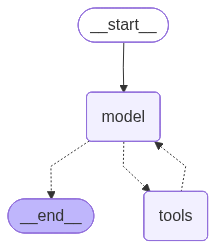

In [22]:
from langchain.agents import create_agent

agent = create_agent(llm_groq, toolkit.get_tools())

agent

In [23]:
# from email import message
example_query = ("How much I earned from mouse sales ")

events = agent.stream(
    {"messages" : [("user", example_query)]},
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

How much I earned from mouse sales 


BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=sql_db_query_checker{"query": "SELECT SUM(salary) FROM mouse_sales"}</function>\n'}}